# 动手实验一：把机器人题画出来

本页所有代码都可以重新运行。先从安全阈值与三角网格开始，再用数值实验观察连续采样为什么可能漏掉危险。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
plt.rcParams['font.sans-serif']=['Microsoft YaHei','SimHei','DejaVu Sans']
plt.rcParams['axes.unicode_minus']=False
ROBOT_RADIUS=1
OBSTACLE_RADIUS=8
SAFE_RADIUS=ROBOT_RADIUS+OBSTACLE_RADIUS
print(f'安全中心距 = {SAFE_RADIUS}')

安全中心距 = 9


## 实验 A：改动圆心距离

蓝圆是机器人，金色圆是障碍物。把 `distance` 改成 8.9、9、9.1，预测再运行。相切时中心距正好为 9，按题目规则仍然合法。

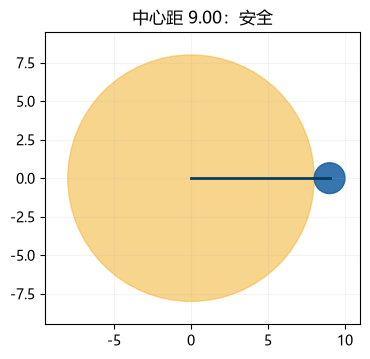

In [2]:
distance=9.0
fig,ax=plt.subplots(figsize=(7,3.8))
ax.add_patch(Circle((0,0),OBSTACLE_RADIUS,color='#F4B942',alpha=.6))
ax.add_patch(Circle((distance,0),ROBOT_RADIUS,color='#145DA0',alpha=.85))
ax.plot([0,distance],[0,0],color='#0B3C5D',lw=2)
ax.set_aspect('equal');ax.set_xlim(-9.5,11);ax.set_ylim(-9.5,9.5)
ax.set_title(f'中心距 {distance:.2f}：'+('安全' if distance>=SAFE_RADIUS else '碰撞'))
ax.grid(alpha=.15);plt.show()

## 实验 B：按整数坐标生成层

论文使用 $\ell(a,b)=\max(|a|,|b|,|a+b|)$。下面的代码不是凭图“猜层数”，而是逐点计算。

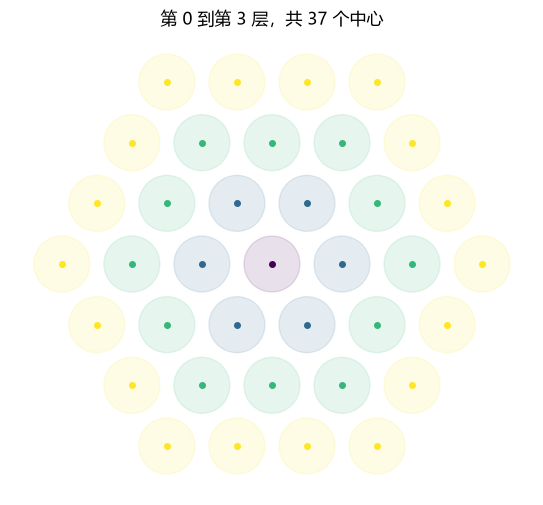

In [3]:
def layer(a,b): return max(abs(a),abs(b),abs(a+b))
def xy(a,b): return 20*a+10*b,10*math.sqrt(3)*b
n=3
pts=[(a,b,*xy(a,b),layer(a,b)) for a in range(-n,n+1) for b in range(-n,n+1) if layer(a,b)<=n]
fig,ax=plt.subplots(figsize=(7,6))
for a,b,x,y,ell in pts:
    ax.add_patch(Circle((x,y),8,alpha=.12,color=plt.cm.viridis(ell/n if n else 0)))
    ax.plot(x,y,'o',color=plt.cm.viridis(ell/n if n else 0),ms=4)
ax.set_aspect('equal');ax.set_title(f'第 0 到第 {n} 层，共 {len(pts)} 个中心');ax.axis('off');plt.show()

## 实验 C：采样密度不是证明

下面故意造一个很窄的危险凹口。稀疏采样可能完全看不到它；加密后才暴露。真实论文使用连续区间证书解决这种问题。

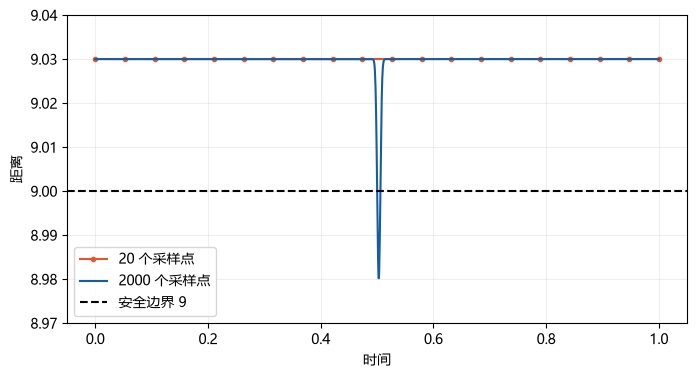

20点最小值: 9.03
2000点最小值: 8.98019279623968


In [4]:
def clearance(t): return 9.03-0.05*np.exp(-((t-0.503)/0.004)**2)
fig,ax=plt.subplots(figsize=(8,4))
for count,color in [(20,'#E4572E'),(2000,'#145DA0')]:
    t=np.linspace(0,1,count);ax.plot(t,clearance(t),'o-' if count==20 else '-',ms=3,label=f'{count} 个采样点',color=color)
ax.axhline(9,color='black',ls='--',label='安全边界 9')
ax.set_ylim(8.97,9.04);ax.set_xlabel('时间');ax.set_ylabel('距离');ax.legend();ax.grid(alpha=.2);plt.show()
print('20点最小值:',clearance(np.linspace(0,1,20)).min())
print('2000点最小值:',clearance(np.linspace(0,1,2000)).min())

## 结论记录

1. 半径相加把圆—圆碰撞化成点—圆判断。
2. 层数公式让几何阵列可以被程序精确枚举。
3. 采样图只帮助发现问题，不能替代连续时间安全证书。
4. 本 Notebook **不重新证明** 445.858 米或 285.492 米；那两个数来自提交研究中的严格见证与各自的信息模型。